In [1]:
import numpy as np
from multiprocessing import Pool, cpu_count

from plot import *
from genData import *

title ='test'

timestamps = np.linspace(0, 128, 128)
frequency = np.linspace(0, 256, 256)

def simNoise(sqrtSn=1, Tsft=7200, size=(256,128), ndet=1, fs=1./60.):
    """
    Generates Gaussian noise in the frequency domain with given parameters.

    Parameters:
        Tsft (float): Total time duration for Fourier transform.
        size (tuple): Shape of each dataset in the form (num_bins, num_segments).
        ndet (int): Number of detector.

    Returns:
        np.ndarray: Generated noise data with shape (num_segments, num_bins, 2*ndet).
    """
    num_bins, num_segments = size
    # sigma in time domain = 1 and therefor in complex domain (real + imag), the variance is half of the original one 
    sigma = 0.5 * sqrtSn * np.sqrt(Tsft * fs)  # Variance for real and imaginary parts 

    dataset = np.empty((num_bins, num_segments, 2*ndet))
    for i in range(ndet):  # Two time series
        dataset[...,2*i] = np.random.normal(0, sigma, size)
        dataset[...,2*i+1] = np.random.normal(0, sigma, size)
        
    return dataset
    #return normalize(dataset)

#fig, ax = plot_spectrograms(title, timestamps, frequency, simNoise(fs=4096,Tsft=1))
    

data = np.load('../unet_dyn2/data/H1L1_D0-10_256x128_7200s_4c_traindata_n10_seed0_n.npz', allow_pickle=True)

25-05-17 14:49:54.166 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
#fig, ax = plot_spectrograms(title, timestamps, frequency, data['noise'][3])
#fig, ax = plot_spectrograms(title, timestamps, frequency, simNoise(Tsft=7200, fs=1))

d = data['noise'][2]

real_std = np.std(d[...,0])
imag_std = np.std(d[...,1])
power = np.mean(d[...,0].flatten()**2 + d[...,1].flatten()**2 )


for _ in range(5):
    n = simNoise(Tsft=7200, fs=1)
    real_stdn = np.std(n[...,0])
    imag_stdn = np.std(n[...,1])
    powern = np.mean(n[...,0].flatten()**2 + n[...,1].flatten()**2 )

    print("\n")
    print((real_stdn-real_std)/real_stdn)
    print((imag_stdn-imag_std)/imag_stdn)
    print((powern-power)/powern)
    



-2.2199191362790945e-05
0.001456128125108597
0.0014620709079535288


-0.0013583661103119585
0.004527652600454445
0.0032815339564784686


-0.003779212389432968
-0.002806101068490197
-0.006581663300947779


-0.0061081520177694
-0.002480963860570779
-0.008569787272831439


0.004131241374277597
-0.0024793469872267143
0.0017863282991923007


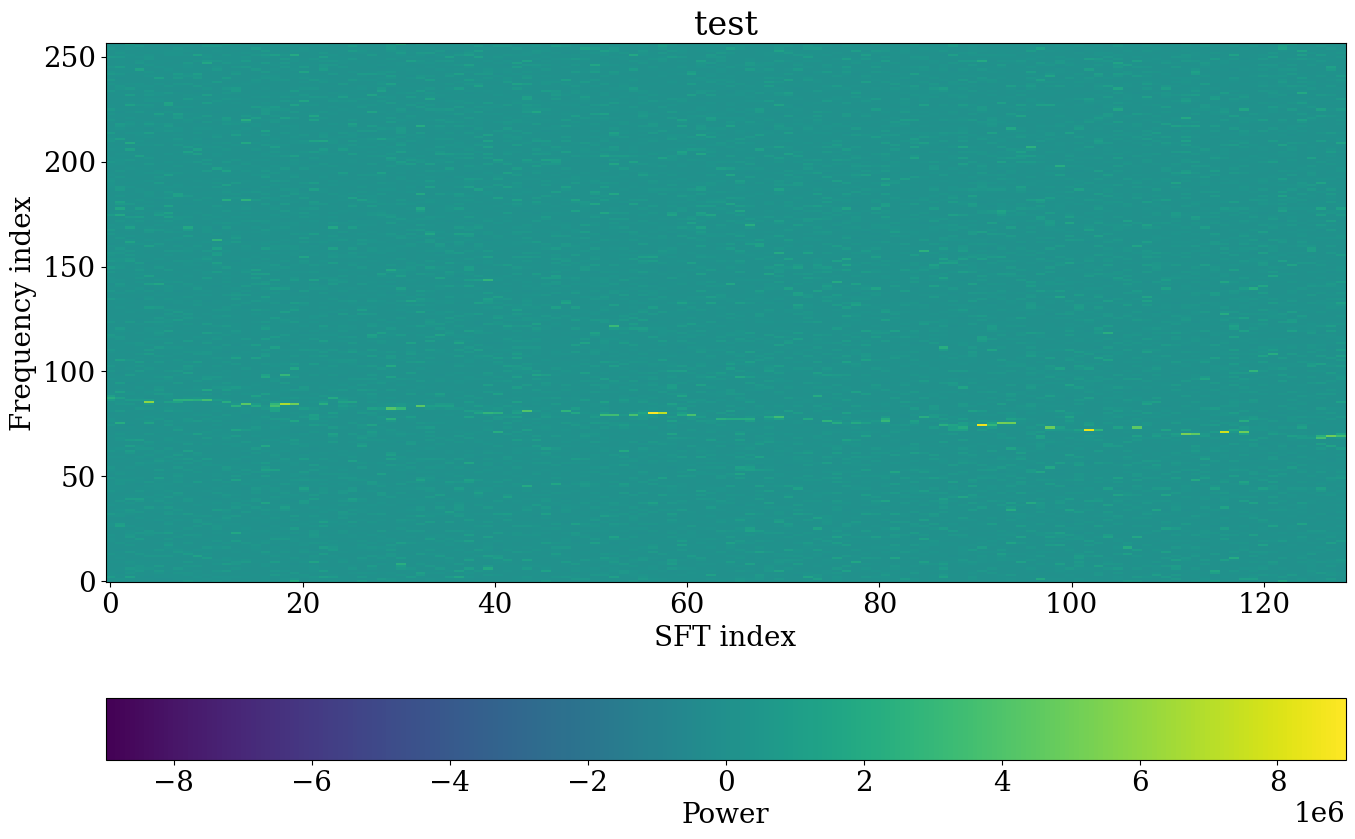

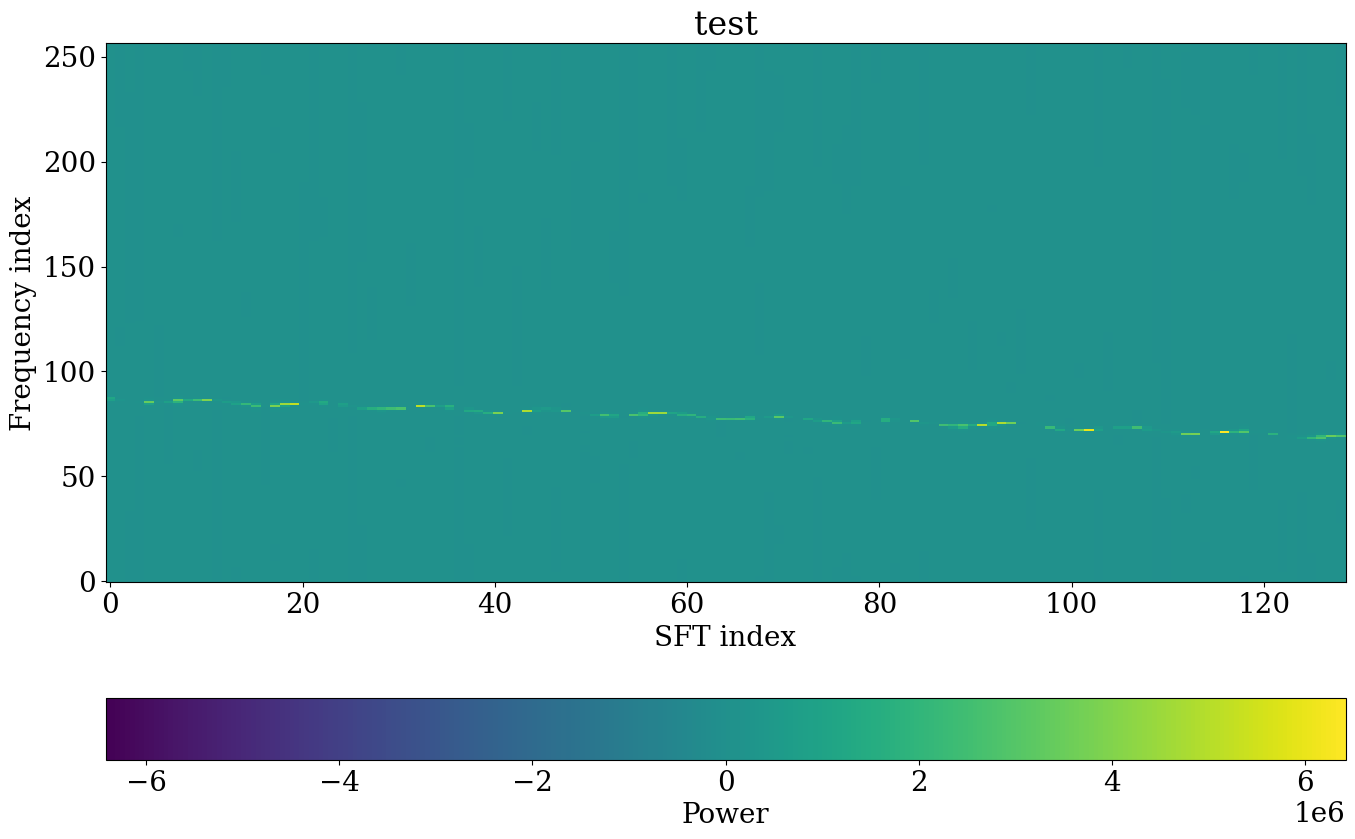

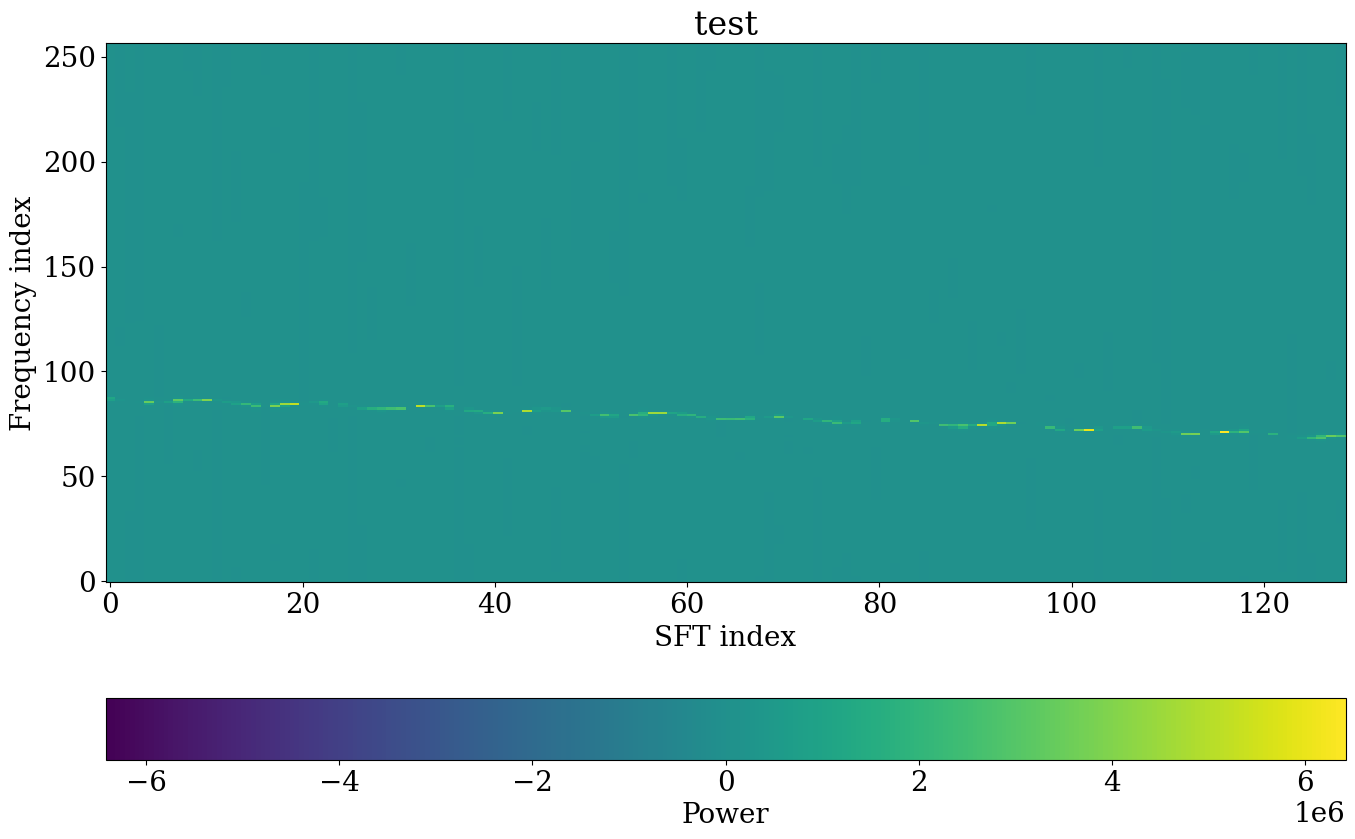

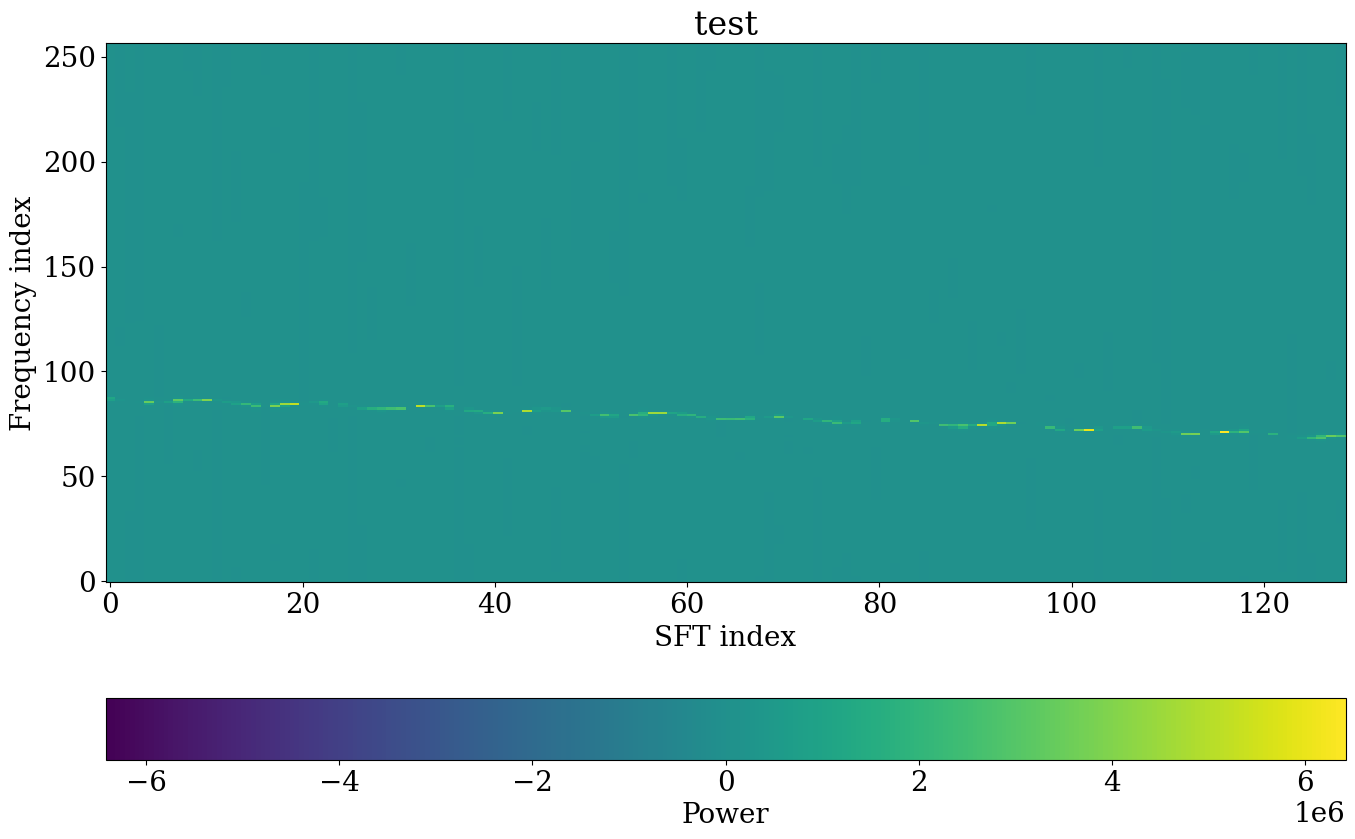

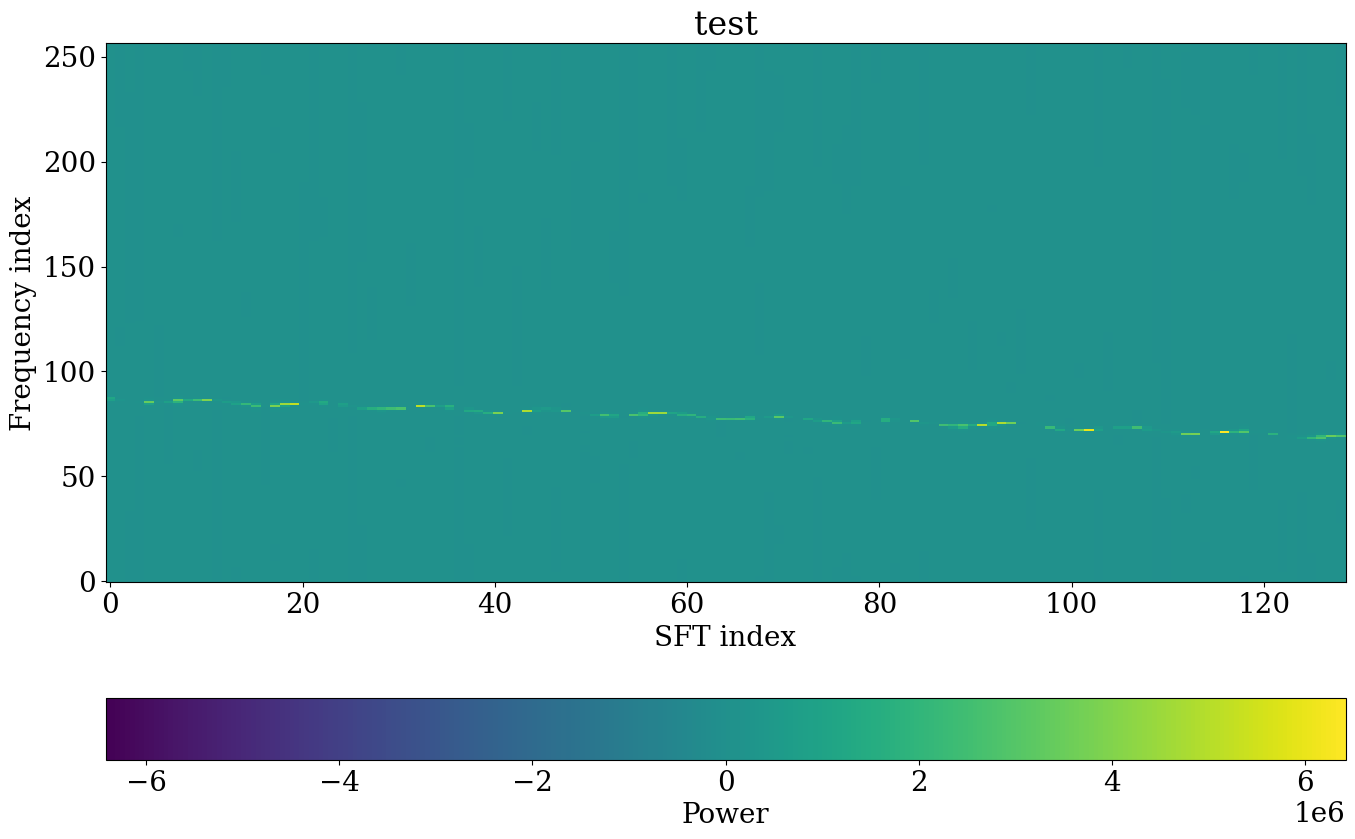

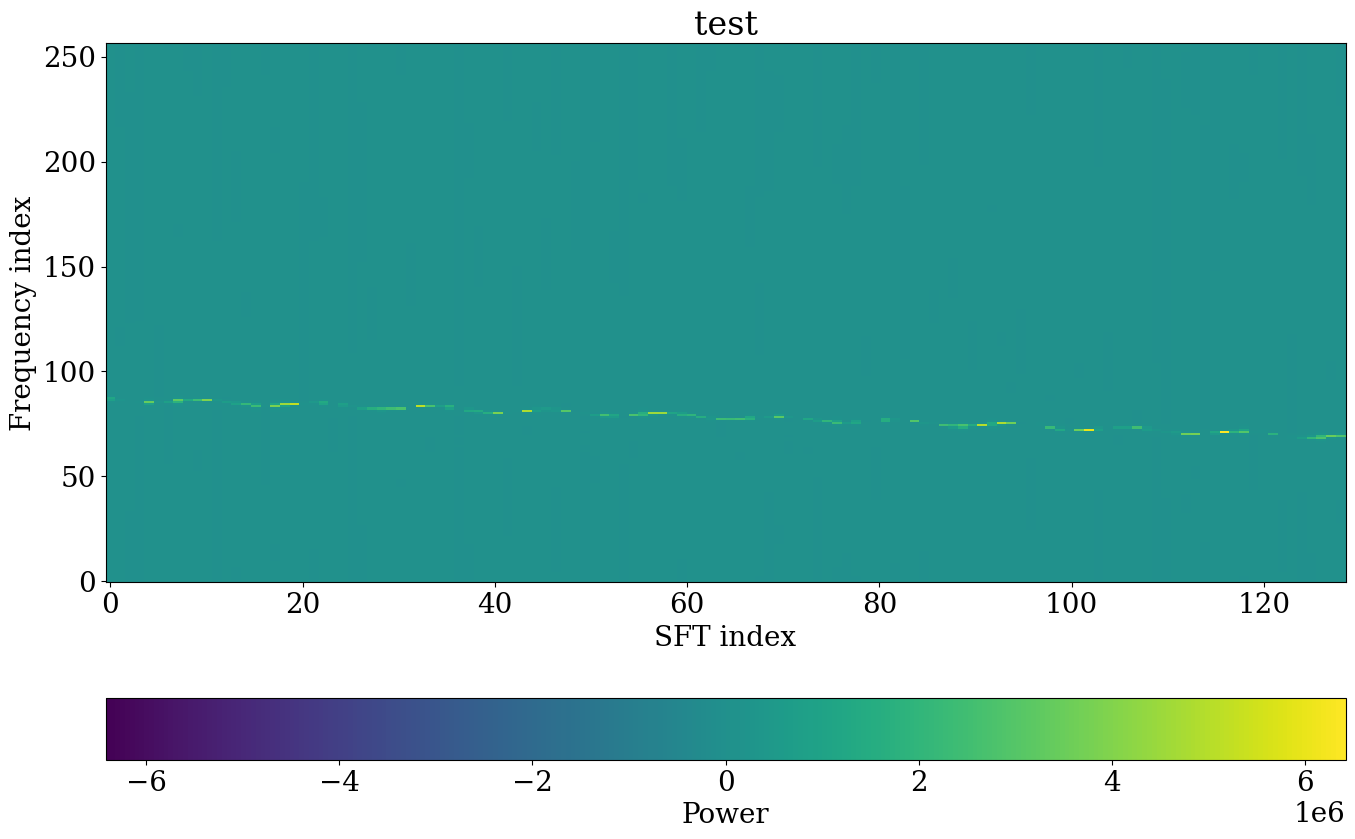

In [2]:
data = np.load('../unet_dyn2/data/H1L1_D0-10_256x128_7200s_4c_traindata_n10_seed0_s+n.npz', allow_pickle=True)
fig, ax = plot_spectrograms(title, timestamps, frequency, data['noisy_image'].item()['10'][0])
for _ in range(5):
    fig, ax = plot_spectrograms(title, timestamps, frequency, data['clean_image'][0] + simNoise(sqrtSn=10, fs=1, Tsft=7200, ndet=2))

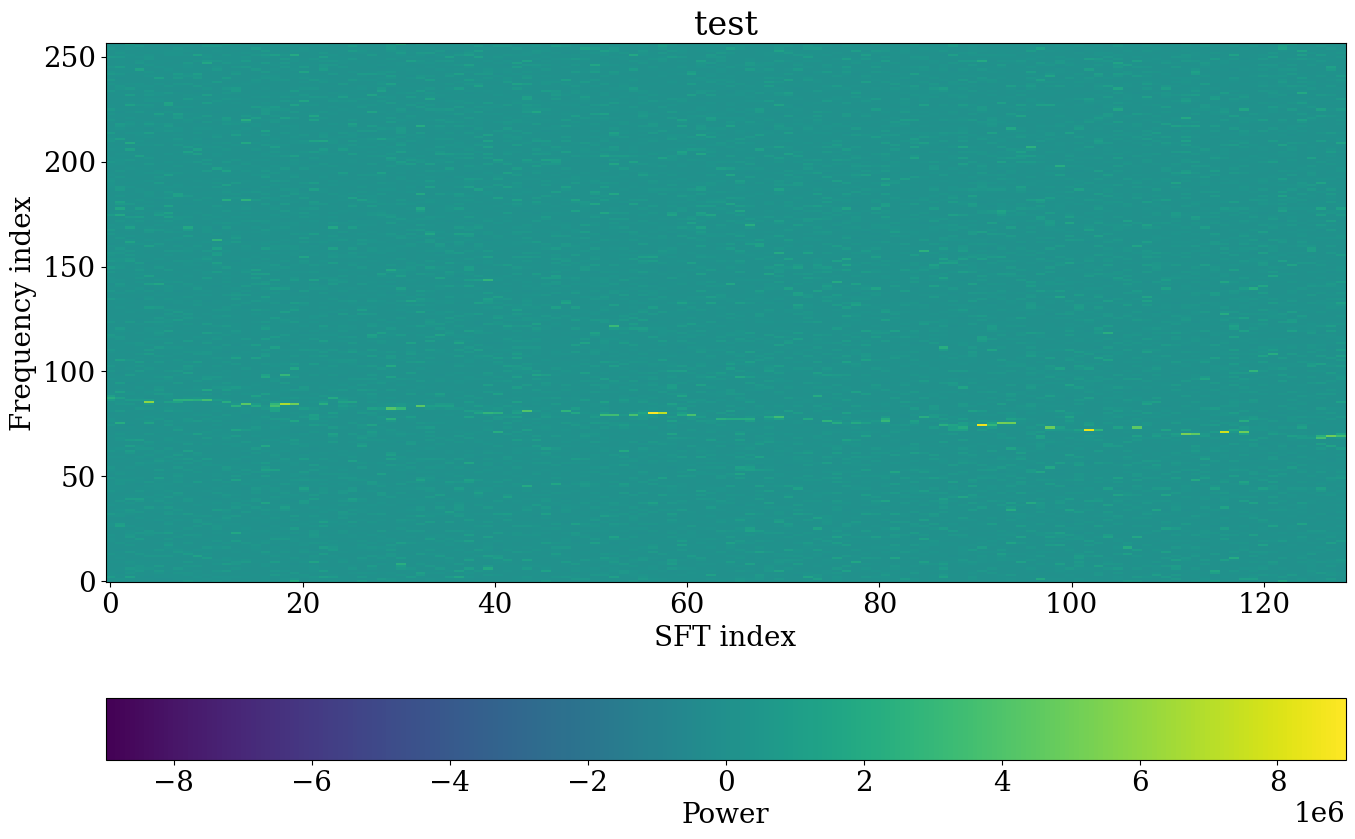

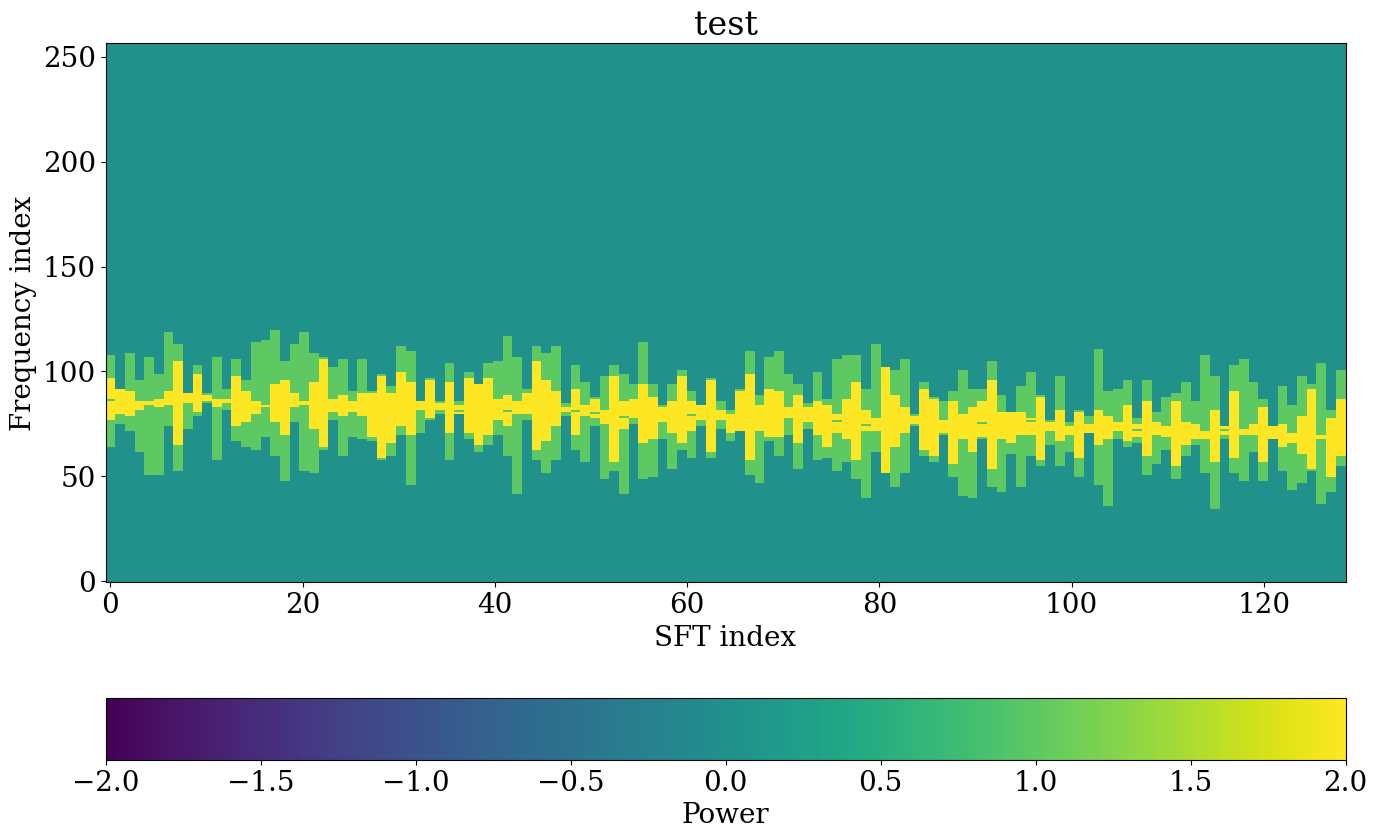

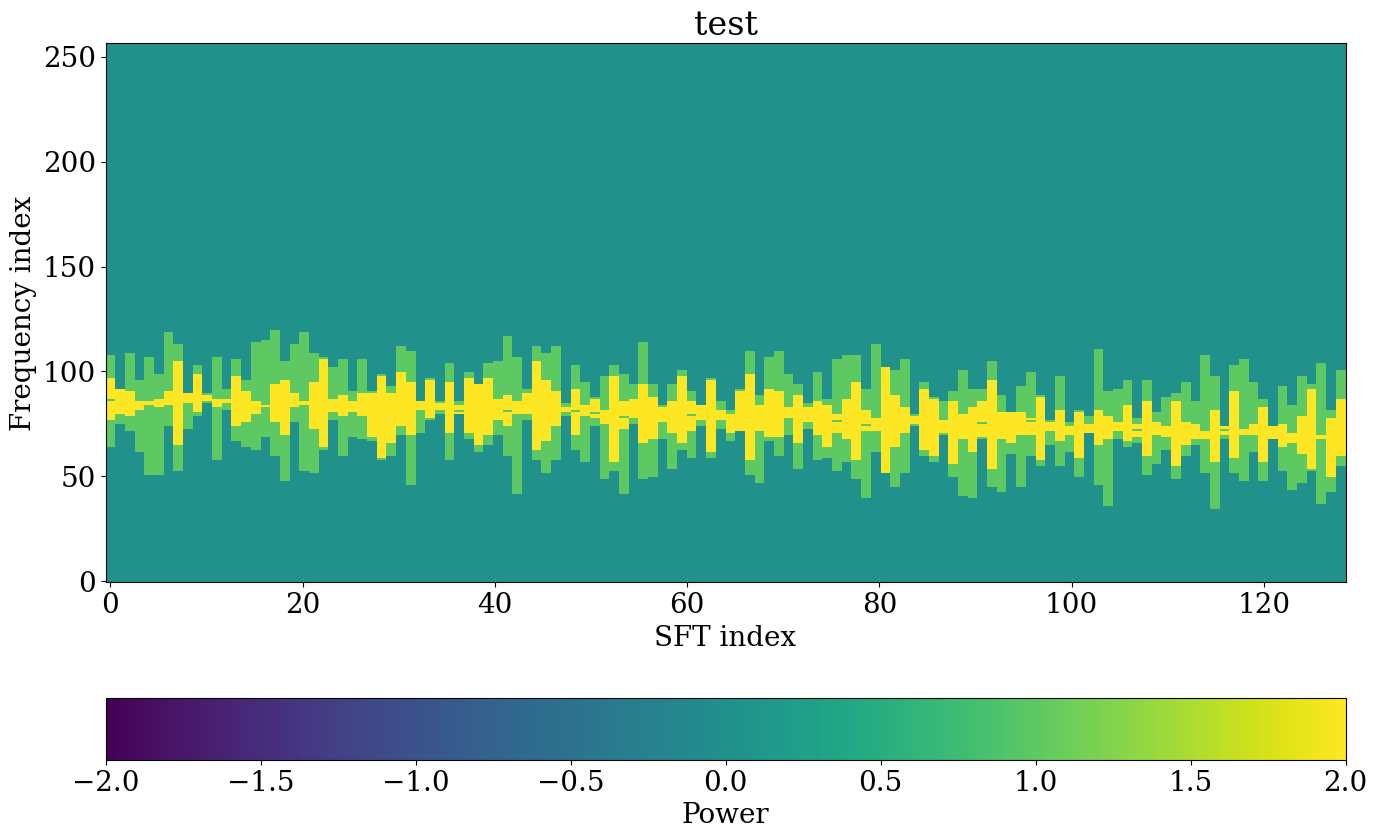

In [5]:
data = np.load('../unet_dyn2/data/H1L1_D0-10_256x128_7200s_4c_traindata_n10_seed0_s+n.npz', allow_pickle=True)
fig, ax = plot_spectrograms(title, timestamps, frequency, data['noisy_image'].item()['10'][0])
for _ in range(2):
    fig, ax = plot_spectrograms(title, timestamps, frequency, data['signal_mask'][0])

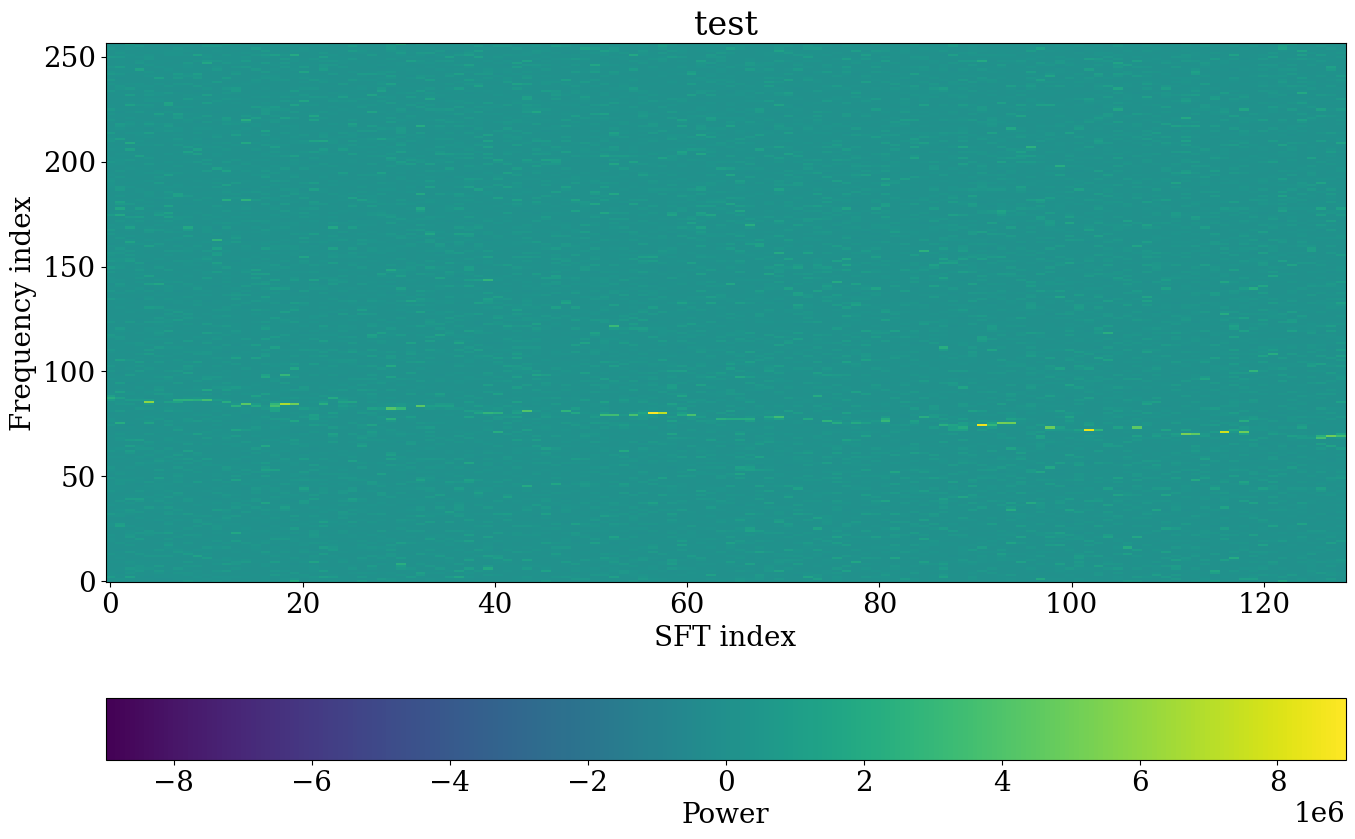

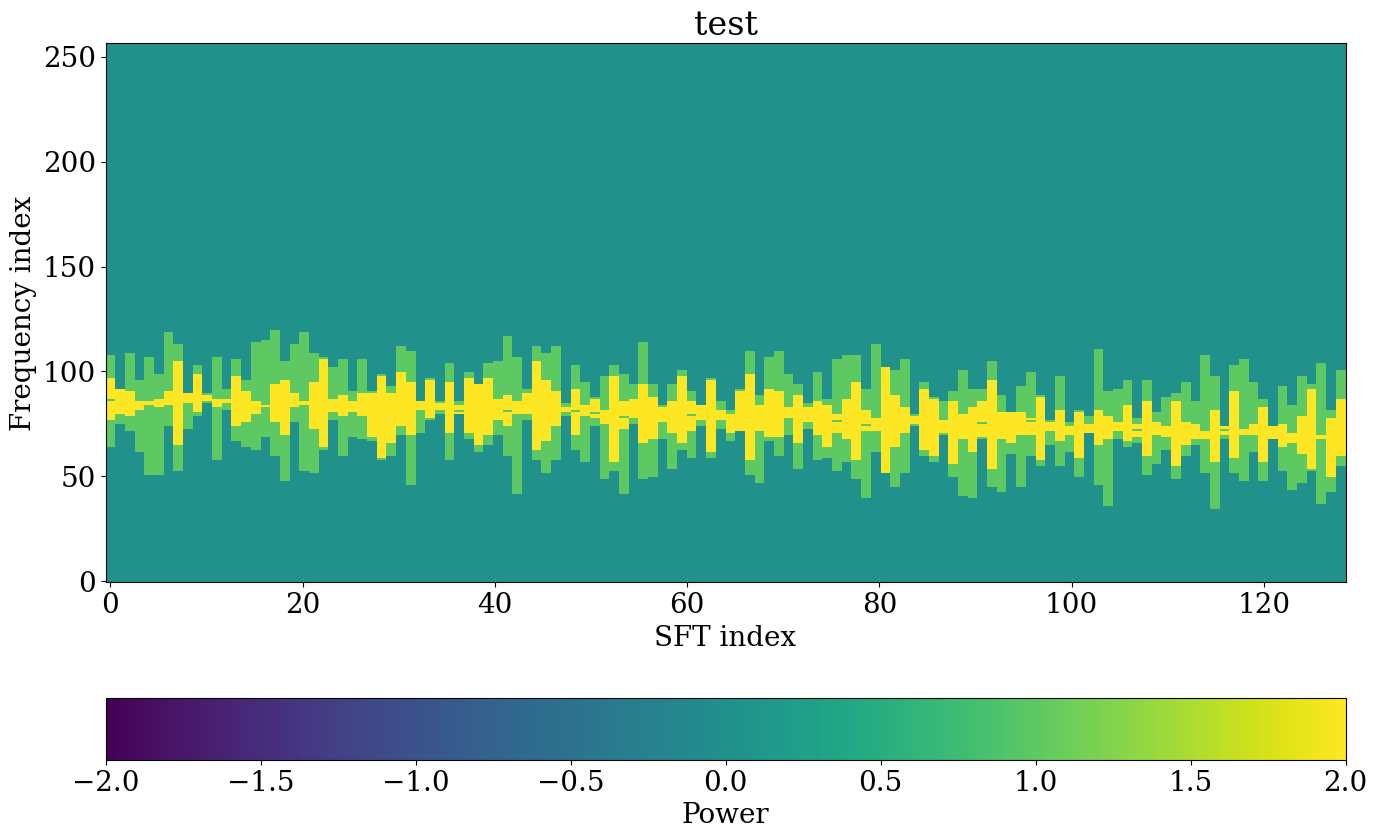

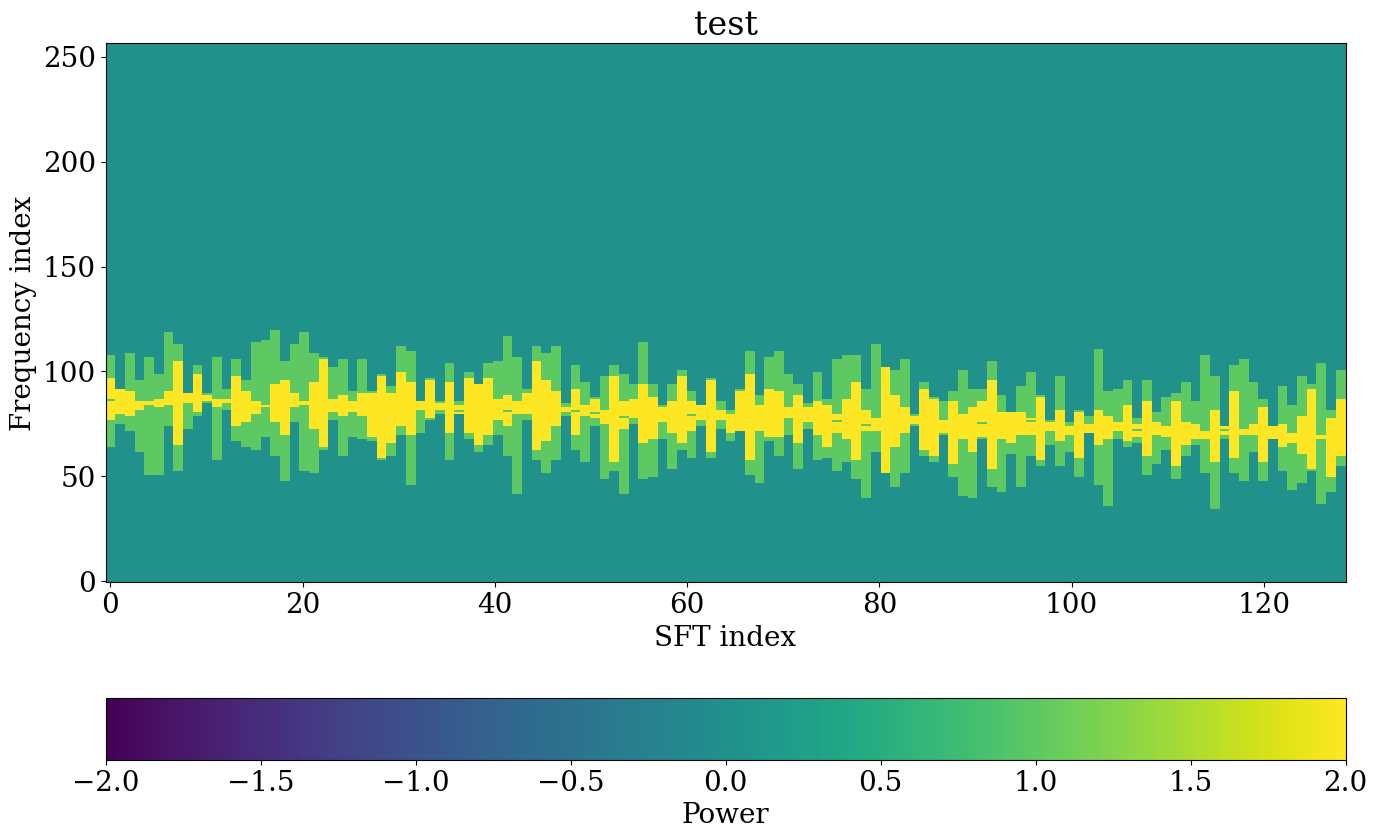

In [28]:
data = np.load('../unet_dyn2/data/H1L1_D0-10_256x128_7200s_4c_traindata_n10_seed0_s+n.npz', allow_pickle=True)
fig, ax = plot_spectrograms(title, timestamps, frequency, data['noisy_image'].item()['10'][0])
for _ in range(2):
    fig, ax = plot_spectrograms(title, timestamps, frequency, data['signal_mask'][0])

In [48]:
x = np.zeros_like(data['clean_image'][0])
x[data['clean_image'][0]>1e2] = 1

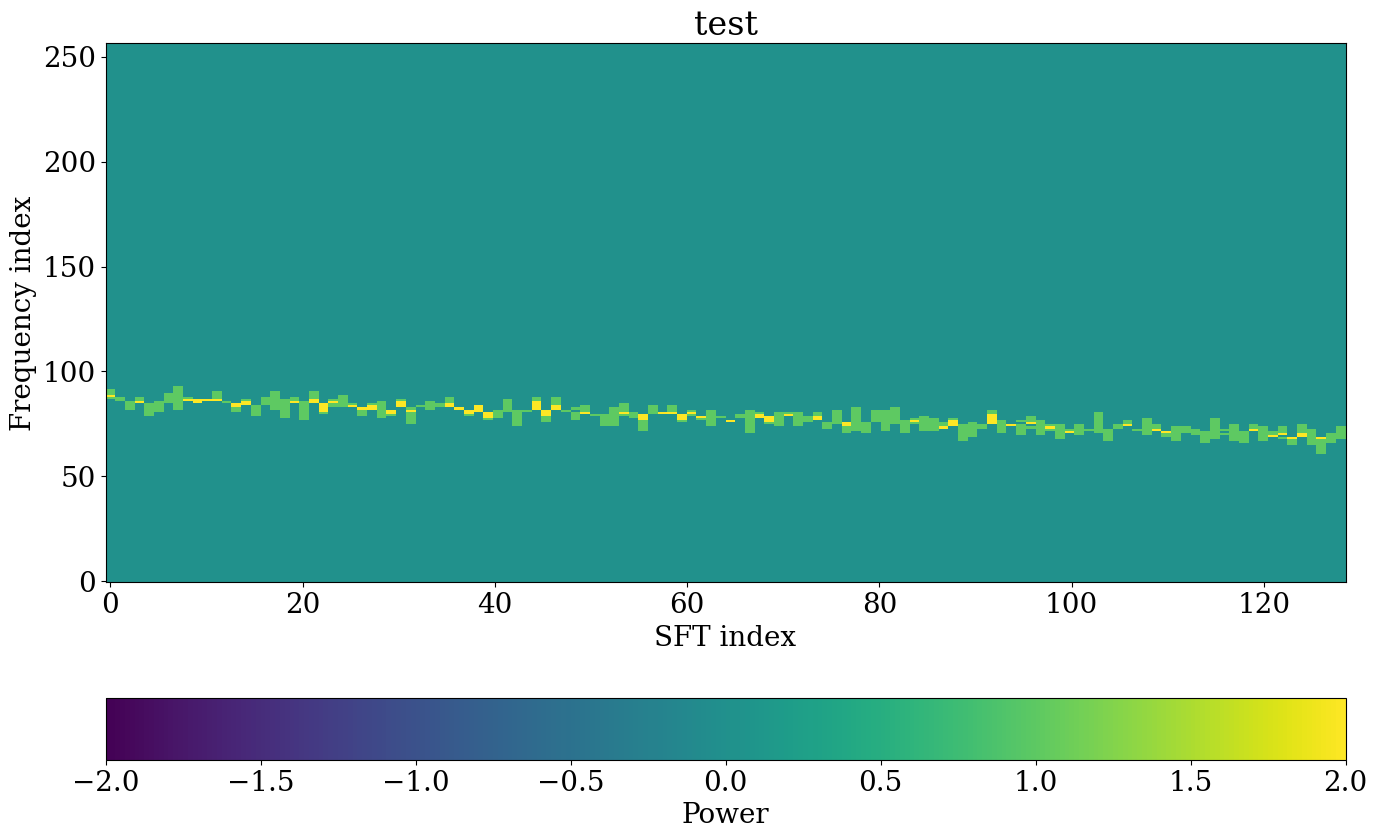

In [49]:
fig, ax = plot_spectrograms(title, timestamps, frequency, x)